# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [1]:
# Enable autoreload so module changes are automatically reloaded
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')
from ForSean.GNN_inferenceVarN import *

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# auto-reload the module

clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
cmap = sns.color_palette("viridis", as_cmap=True)


2026-02-05 16:17:21.737161: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load and Prepare Data


In [3]:
## Note: change datadir to your own path

dataname = "outputVariableNodes_kappa0.2_temp0.1_trajlen300_dt0.01_N20_seed1_damp50frame10.csv" #for sure variable nodes
datadir = '//Users/billiemeadowcroft/Dropbox/PostDocCode/Github_SFI/GNN_Inference/ForSean/'
data = load_data(datadir, dataname)



Data loaded: (3680, 6)
Columns: ['frame', 'particle', 'x', 'y', 'z', 'mass']
Number of frames: 301


## Calculate derivatives (velocities and accelerations)


In [4]:
frame = 10
delta_t = 0.01
dt = delta_t*frame
T_weak = False #False #True
T_Naive = True
tau = 16
print("length of data: ", len(data))
print("Total unique particles: ", len(data['particle'].unique()))
print("for naive derivative, should be losing 2x the number of particles",len(data)-len(data['particle'].unique())*2)
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = 6)
#how much of the total data has zero ax and ay?
print(f"Fraction of data with zero ax and ay: {len(data_clean[data_clean['ax'] == 0])/len(data_clean)}")

data_clean = data_clean[data_clean['ax'] != 0]
data_clean = data_clean[data_clean['ay'] != 0]
print(f"Fraction of data with non-zero ax and ay: {len(data_clean[data_clean['ax'] != 0])/len(data_clean)}")
print("Length of data_clean: ", len(data_clean))



length of data:  3680
Total unique particles:  40
for naive derivative, should be losing 2x the number of particles 3600
Calculating derivatives...
Processing 40 particles...
Calculating naïve derivatives...
length of data_clean:  3680
how much of the data has zero ax and ay:  0.020380434782608696
After removing boundary frames: (3680, 10)
Acceleration statistics:
  ax: mean=0.014, std=0.683
  ay: mean=0.014, std=0.608
Fraction of data with zero ax and ay: 0.020380434782608696
Fraction of data with non-zero ax and ay: 1.0
Length of data_clean:  3604


## (optional) Plotting some acceleration data of a single particle


20       1
21       2
22       3
23       4
24       5
        ..
3667    29
3668    30
3669    33
3670    40
3671    35
Name: particle, Length: 3604, dtype: int64
    frame  particle        x        y         z  mass       vx       vy  \
22      1         3 -2.19757  1.94309 -0.028965   1.0 -0.04685  0.25720   
38      2         3 -2.20004  1.97250 -0.019131   1.0  0.00945  0.31875   
54      3         3 -2.19568  2.00684 -0.010960   1.0  0.08590  0.35005   
70      4         3 -2.18286  2.04251 -0.002702   1.0  0.16755  0.35850   
86      5         3 -2.16217  2.07854  0.005774   1.0  0.24635  0.33755   

       ax     ay  
22  0.443  0.738  
38  0.683  0.493  
54  0.846  0.133  
70  0.787  0.036  
86  0.789 -0.455  


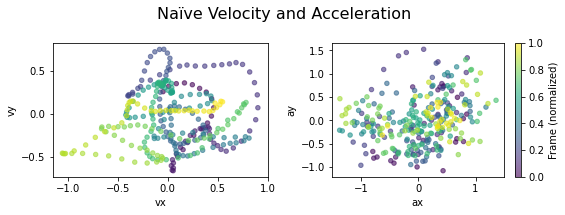

In [ ]:

print(data_clean['particle'])
data_1particle = data_clean[data_clean['particle'] == 3]
print(data_1particle.head())

fig,ax = plt.subplots(1,2,figsize=(8,3))
cmap = plt.cm.viridis
normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                    (data_1particle['frame'].max() - data_1particle['frame'].min())
ax[0].scatter(data_1particle['vx'],data_1particle['vy'],
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[0].set_xlabel('vx')
ax[0].set_ylabel('vy')
ax[1].scatter(data_1particle['ax'], data_1particle['ay'], 
              c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
ax[1].set_xlabel('ax')
ax[1].set_ylabel('ay')
plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
#ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
# put central title for whole figure
if T_Naive:
    fig.suptitle('Naïve Velocity and Acceleration', fontsize=16)
else:
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau =$'+str(tau), fontsize=16)
fig.tight_layout()
scale = 1
if T_weak and T_Naive:
    fig,ax = plt.subplots(1,2,figsize=(8,3))
    cmap = plt.cm.viridis
    normalized_frames = (data_1particle['frame'] - data_1particle['frame'].min()) / \
                        (data_1particle['frame'].max() - data_1particle['frame'].min())
    ax[0].scatter(np.multiply(data_1particle['Wvx'],scale),np.multiply(data_1particle['Wvy'],scale),
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[0].set_xlabel('Wvx')
    ax[0].set_ylabel('Wvy')
    ax[1].scatter(data_1particle['Wax'], data_1particle['Way'], 
                c=normalized_frames, cmap=cmap, s=20, alpha=0.6)
    ax[1].set_xlabel('Wax')
    ax[1].set_ylabel('Way')
    plt.colorbar(ax[1].collections[0],label='Frame (normalized)')
    #ax[0].plot(data_clean['ay'],color = clrs[1],linestyle = '--',label = 'ay')
    # put central title for whole figure
    fig.suptitle(r'Weak form Velocity and Acceleration for $\tau = $'+str(tau), fontsize=16)
    fig.tight_layout()
    ax[1].set_xlabel('ax')
    ax[1].set_ylabel('ay')
    ax[1].set_ylim([-2,2])
    ax[1].set_xlim([-2,2])
    ax[0].set_ylim([-1.2,1.2])
    ax[0].set_xlim([-1.2,1.2])

## Build dataset as graph


In [10]:
# Prepare dataset with graph structure
dataset = prepare_dataset(data_clean, cutoff=3.0, max_frames=300)

# Split into train/val/test
# get rid of the frames which have zero ax and ay

#train_data, val_data, test_data = split_dataset(dataset)


Preparing dataset from 299 frames...
processing frame  1
processing frame  2
processing frame  3
processing frame  4
processing frame  5
processing frame  6
processing frame  7
processing frame  8
processing frame  9
processing frame  10
processing frame  11
processing frame  12
processing frame  13
processing frame  14
processing frame  15
processing frame  16
processing frame  17
processing frame  18
processing frame  19
processing frame  20
processing frame  21
processing frame  22
processing frame  23
processing frame  24
processing frame  25
processing frame  26
processing frame  27
processing frame  28
processing frame  29
processing frame  30
processing frame  31
processing frame  32
processing frame  33
processing frame  34
processing frame  35
processing frame  36
processing frame  37
processing frame  38
processing frame  39
processing frame  40
processing frame  41
processing frame  42
processing frame  43
processing frame  44
processing frame  45
processing frame  46
proces

## Split dataset

In [11]:
train_data, val_data, test_data = split_dataset(dataset)

Data splits:
  Train: 209
  Val:   44
  Test:  46


## (Optional) Plot an example graph of one frame (Check connectivity)

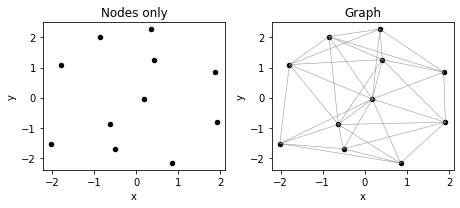

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 3))

# Get first frame from train_data
frame_data = train_data[0]  # Fixed: get first element of list

# Plot nodes on both subplots
for i in range(2):
    ax[i].scatter(frame_data['nodes'][:, 0], frame_data['nodes'][:, 1], 
                  color='black', s=20)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    #ax[i].set_aspect('equal')

# Plot edges on second subplot
edges = frame_data['edges']
for i in range(edges.shape[1]):
    source_idx = edges[0, i]
    target_idx = edges[1, i]
    
    # Get positions
    x_source, y_source = frame_data['nodes'][source_idx][:2] #first two node features are position
    x_target, y_target = frame_data['nodes'][target_idx][:2]
    
    # Plot line from source to target
    ax[1].plot([x_source, x_target], 
               [y_source, y_target], 
               color='gray', alpha=0.5, linewidth=0.5)

ax[0].set_title('Nodes only')
ax[1].set_title('Graph')
fig.tight_layout()

## Create and Train Model


In [13]:
# Create model
model = create_model(hidden_dim=32)

# Train model
model, history = train_model(model, train_data, val_data, num_epochs=60)


ForceGNN model created with hidden_dim=32, gamma_init=0.0

Training for 60 epochs...
Epoch   0: Train Loss = 0.372430, Val Loss = 0.336221
Epoch  10: Train Loss = 0.266641, Val Loss = 0.275483
Epoch  20: Train Loss = 0.041844, Val Loss = 0.038870
Epoch  30: Train Loss = 0.039359, Val Loss = 0.034531
Epoch  40: Train Loss = 0.038662, Val Loss = 0.032872
Epoch  50: Train Loss = 0.038040, Val Loss = 0.033113
Epoch  59: Train Loss = 0.037691, Val Loss = 0.034048

Training complete!


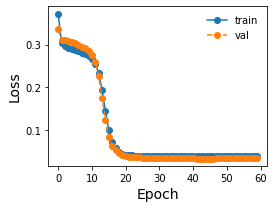

In [17]:
# Plot training history
fig,ax  = plt.subplots(figsize = (4,3))
ax.plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax.plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val',marker = 'o')
ax.legend(frameon = False)
ax.set_xlabel('Epoch',fontsize = 14)
ax.set_ylabel('Loss',fontsize = 14)
fig.tight_layout()


## these are the true pairwise and environment forces on this dataset


In [18]:

def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return dEdr

def force_environment(x,y,kappa_x,kappa_y,x_0,y_0):
    r_vec = np.array([x-x_0,y-y_0])
    r = np.linalg.norm(r_vec)
    Fx = -kappa_x*(x-x_0)
    Fy = -kappa_y*(y-y_0)
    return np.array([Fx,Fy])
    

## Query pairwise forces

In [20]:
# Get force at a specific distance
sigma = 1.5
l_da = 0.1
rcut = sigma*2
epsilon = 0.5
r_arr = np.linspace(0.3,3.5,100)
force_infer = []
force_true = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r))
    force_true.append(soft_lj_force(r, epsilon, sigma, rcut, l_da))
    #print(f"Force at distance r={r}: {force:.6f}")


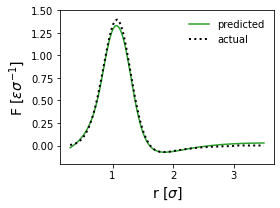

In [21]:


fig,ax  = plt.subplots(figsize = (4,3))
scaleF = 1.5
#ax.plot(r_arr,np.multiply(force_infer,scaleF),color = clrs[1],linestyle = '-',label = 'predicted*'+str(scaleF))
ax.plot(r_arr,np.multiply(force_infer,1),color = clrs[2],linestyle = '-',label = 'predicted')
ax.plot(r_arr,list(force_true),color = 'black',linestyle = ':',label = 'actual',linewidth = 2)
ax.set_xlabel('r [$\sigma$]',fontsize = 14)
ax.set_ylabel('F [$\epsilon \sigma^{-1}$]',fontsize = 14)
ax.set_ylim([-0.2,1.5])

ax.legend(frameon = False)
fig.tight_layout()

## Evaluate model, find $R^2$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Test Set Evaluation:
  MSE: 0.038015
  MAE: 0.151290
Average R^2: 0.9073


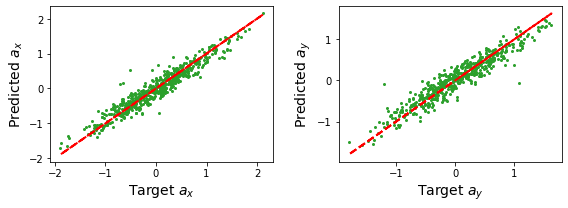

In [23]:
# Plot predictions vs actual
#plot_predictions(evaluation)
evaluation = evaluate_model(model, test_data)

# Retrieve flattened predictions/targets
predictions = evaluation['predictions']
targets = evaluation['targets']
residuals = predictions - targets
if 'mask' in evaluation:
       mask_flat = np.concatenate([d['mask'] for d in test_data])
       masked_targets = targets[mask_flat == 1]
       if np.any(masked_targets[:, 0] == 0):
           print("Found zero in MASKED targets - this is a problem!")
# Component-wise error statistics
mse_vx = np.mean(residuals[:, 0]**2)
mse_vy = np.mean(residuals[:, 1]**2)
var_vx = np.var(targets[:, 0])
var_vy = np.var(targets[:, 1])
r2_vx = 1 - mse_vx / var_vx if var_vx > 0 else np.nan
r2_vy = 1 - mse_vy / var_vy if var_vy > 0 else np.nan
print(f"Average R^2: {(r2_vx+r2_vy)/2:.4f}")
fig,ax = plt.subplots(1,2,figsize = (8,3))
ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = clrs[2],linestyle = '',markersize = 2)
ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = clrs[2],linestyle = '',markersize = 2)
ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
if np.any(targets[:,0] ==0):
    print("Somehow we have zero acceleraion targets even though we have masked the zero acceleraion nodes")
ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
ax[0].legend(frameon = False)
fig.tight_layout()


## Query environmental force

In [24]:
# Plot force components for a test frame
kappa_x = 0.4
kappa_y = 0.2
#doesn't F_env have a direction?
x_arr = np.linspace(0,2,50)
y_arr = np.linspace(0,2,50)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model, x, y)
        F_env_true[i,j,:] = force_environment(x,y,kappa_x,kappa_y,0,0)

# Plot force components for a test frame

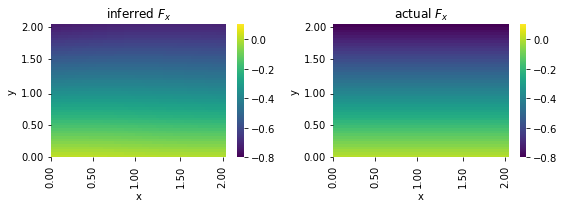

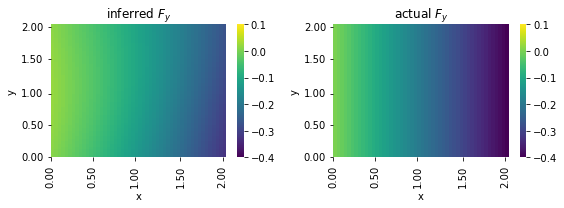

In [25]:
fig,ax = plt.subplots(1,2,figsize = (8,3))
x_ticks = np.linspace(0,2,5)
y_ticks = np.linspace(0,2,5)
x_tick_indices = [np.argmin(np.abs(x_arr - val)) for val in x_ticks]
y_tick_indices = [np.argmin(np.abs(y_arr - val)) for val in y_ticks]

# Create heatmaps
sns.heatmap(F_env_infer[:,:,0], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.8,vmax = 0.1)

sns.heatmap(F_env_true[:,:,0], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.8,vmax = 0.1)

# Set tick positions
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])


ax[0].invert_yaxis()
ax[1].invert_yaxis()
##ax[0].set_xticks(ax[0].get_xticks()[::4])
#ax[1].set_xticks(ax[1].get_xticks()[::4])
ax[0].set_title(r'inferred $F_x$')
ax[1].set_title(r'actual $F_x$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()
fig,ax = plt.subplots(1,2,figsize = (8,3))
sns.heatmap(F_env_infer[:,:,1], ax=ax[0], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.4,vmax = 0.1)

sns.heatmap(F_env_true[:,:,1], ax=ax[1], cmap='viridis',
            xticklabels=[f'{x:.2f}' for x in x_ticks],
            yticklabels=[f'{y:.2f}' for y in y_ticks],vmin=-0.4,vmax = 0.1)
ax[0].invert_yaxis()
ax[1].invert_yaxis()
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks])
ax[0].set_title(r'inferred $F_y$')
ax[1].set_title(r'actual $F_y$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()
